<div style="font-family: 'Vazirmatn', Tahoma, sans-serif; direction: rtl; background: linear-gradient(135deg, #052E2B 0%, #134E4A 60%, #115E59 100%); border-radius: 16px; padding: 30px 40px; margin: -16px -16px 20px -16px; position: relative; overflow: hidden; text-align: center;">
  <div style="font-size: 28pt; font-weight: 700; color: #CCFBF1; margin: 0 0 12px;">داده‌کاوی</div>
  <div style="font-size: 16pt; font-weight: 500; color: #99F6E4; margin: 0 0 12px;">دانشگاه آزاد شیراز — دانشکده مهندسی کامپیوتر</div>
  <span style="display: inline-block; background: #FEF3C7; color: #134E4A; font-size: 14pt; font-weight: 600; padding: 6px 18px; border-radius: 20px; margin-bottom: 20px;">ترم اول سال تحصیلی ۱۴۰۶-۱۴۰۵</span>
  <hr style="border: none; height: 1px; background: rgba(255,255,255,0.15); margin: 20px 0;"/>
  <div style="font-size: 18pt; font-weight: 700; color: #FEF3C7; margin: 0 0 16px;">فصل دوم: Data, measurements, and data preprocessing</div>
  <div style="background: rgba(255,255,255,0.08); border-radius: 10px; padding: 16px 20px; font-size: 15pt; color: #CCFBF1; line-height: 2.2;">
    <b style="color: #CCFBF1; font-weight: 600;">استاد:</b> <span style="color: #F8FAFC;">دکتر امین اسکندری</span><br>
    <b style="color: #CCFBF1; font-weight: 600;">تیم طراحی:</b> <span style="color: #F1F5F9;">حمید نامجو، امیرحسین همتی، امیرمحمد اسدجو، علی نیکوان، رضا لیاقت، علیرضا مقدس، گلنوش حسین‌پور، الهام ایزدی</span>
  </div>
</div>

<div id="c2-s3-9" style="font-family: 'Vazirmatn', Tahoma, sans-serif; direction: ltr;; color: #3D5A47; border-radius: 10px; padding: 10px 10px; font-size: 18pt; font-weight: 700; margin: 0px 0 10px; display: flex; align-items: center; gap: 10px;">
  <span style="font-size: 20pt;"></span> 2.3.9 Capturing hidden semantics in similarity measures
</div>


<div style="font-family: 'Vazirmatn', Tahoma, sans-serif; direction: rtl; border-radius: 0 10px 10px 0; padding: 16px 20px; margin: 14px 0; border-right: 5px solid #B45309; font-size: 15pt; line-height: 2.2; background: #FFFBEB; color: #78350F; box-sizing: border-box;">

  <div style="font-size: 16pt; text-align: center; font-weight: 700; margin-bottom: 8px; color: #B45309;">
    مثال عملی: کشف رابطه معنایی کلمات با الگوریتم Word2Vec 🔍
  </div>

  <p style="font-size: 15pt; text-align: right; margin: 0 0 10px;">
    در پردازش زبان طبیعی و داده‌کاوی متون، کلماتی مانند <b>"tire" (لاستیک)</b> و <b>"wheel" (چرخ)</b> ظاهر و حروف کاملاً متفاوتی دارند. اگر از مقایسه متنی ساده استفاده کنیم، سیستم هیچ ارتباطی بین آن‌ها پیدا نمی‌کند. اما الگوریتم <b>Word2Vec</b> با بررسی کلمات همسایه در متن، <b>معنای پنهان (Hidden Semantics)</b> را کشف کرده و کلمات هم‌مفهوم را در فضای برداری نزدیک به هم قرار می‌دهد.
  </p>

  <p style="font-size: 15pt; text-align: right; margin: 0 0 10px;">
    <b>روش کار Word2Vec:</b><br>
    الگوریتم بر اساس فرضیه توزیعی (Distributional Hypothesis) عمل می‌کند: «کلماتی که در بافت‌ها و جملات مشابهی ظاهر می‌شوند، معانی مشابهی دارند». این الگوریتم هر کلمه را به یک بردار عددی فشرده (مثلاً ۱۰ بعدی) تبدیل می‌کند و سپس با <b>شباهت کسینوسی</b>، میزان هم‌راستایی بردارها سنجیده می‌شود.
  </p>

  <p style="font-size: 15pt; text-align: right; margin: 0;">
    <div style="text-align:center; font-weight:bold;">
      خروجی: تبدیل کلمات متنی به بردارهای عددی معنایی و محاسبه شباهت کسینوسی کلمات هم‌مفهوم
    </div>
  </p>

</div>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from gensim.models import Word2Vec 

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", rc={
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

plt.rcParams['figure.dpi'] = 135

np.random.seed(42)

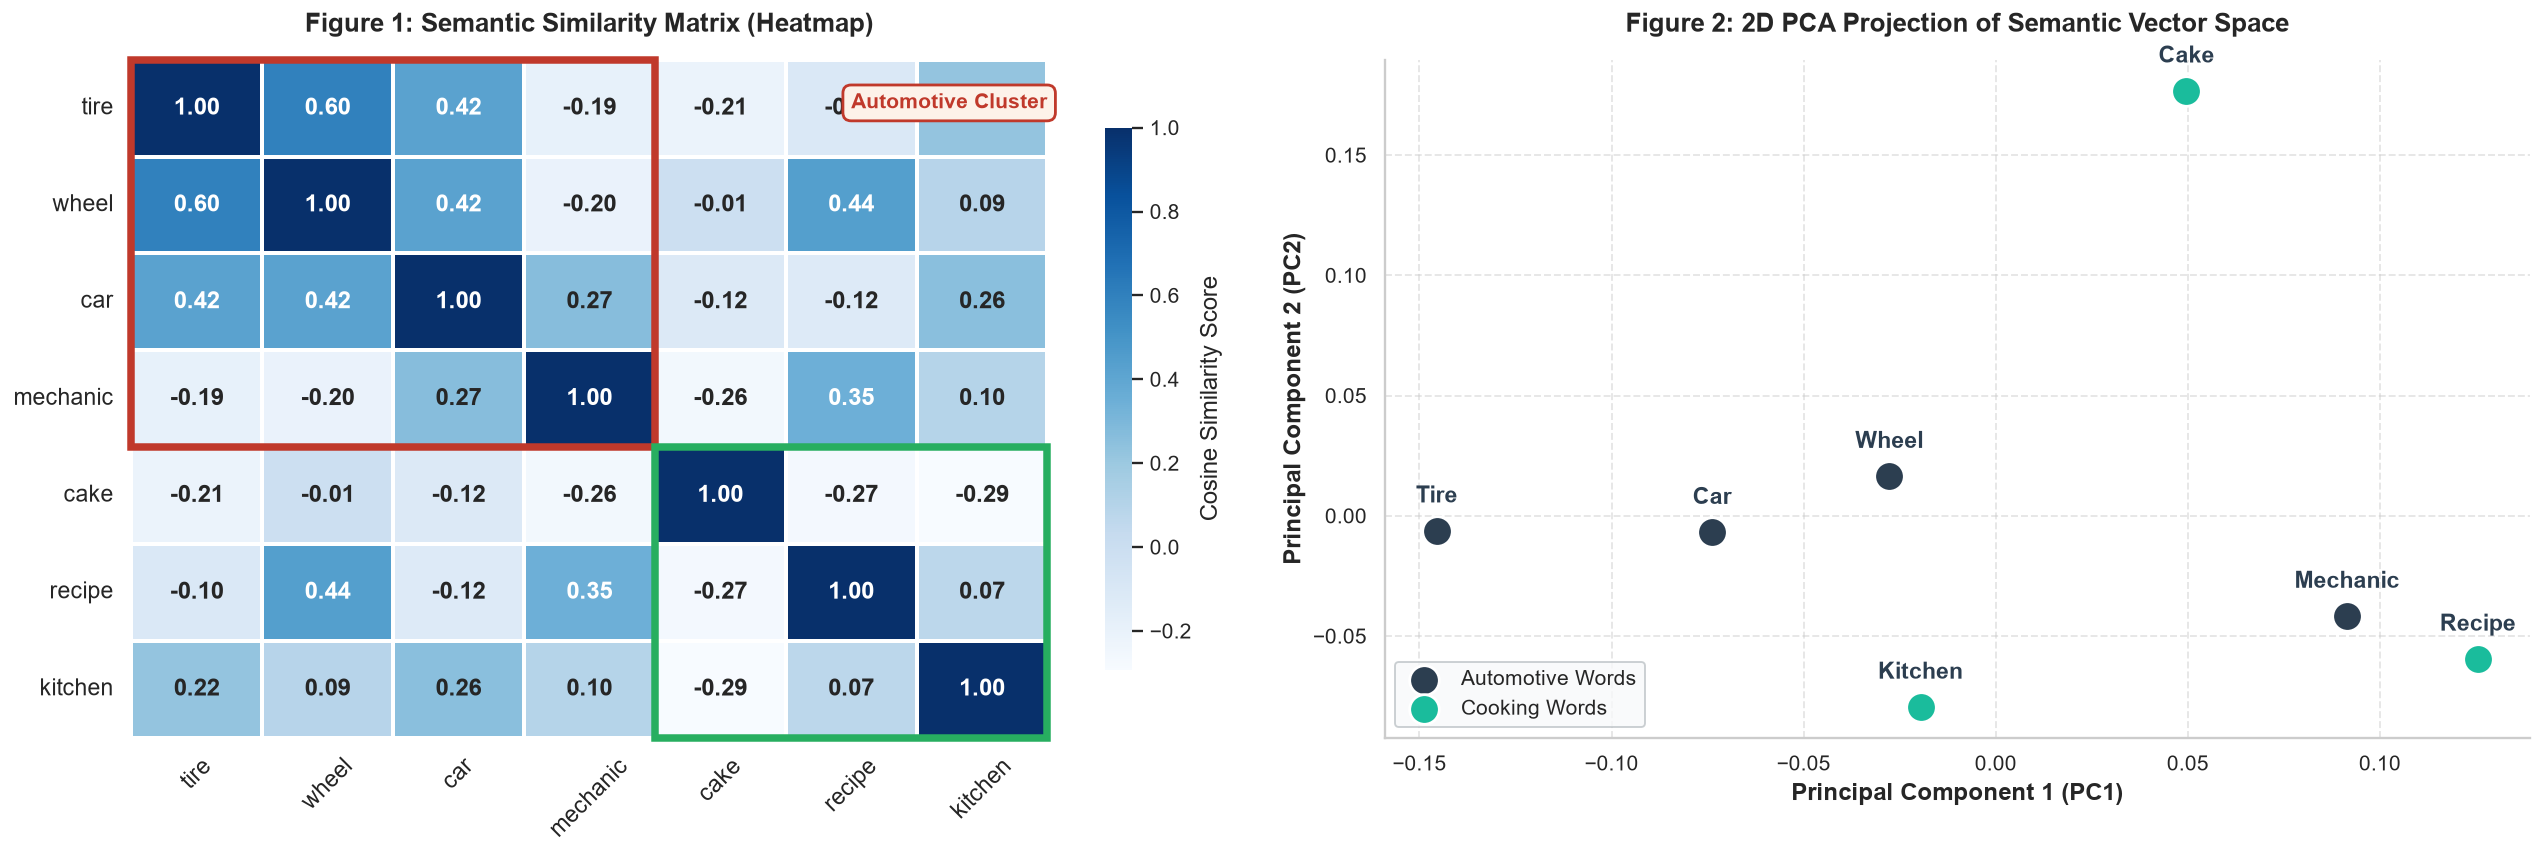

In [27]:
display_academic_text(
    "پردازش زبان طبیعی (NLP): استخراج روابط معنایی با شبکه‌های عصبی Word2Vec 🧠", 
    "main_title"
)

display_academic_text(
    "در تحلیل هوشمند متون، کلماتی مانند «لاستیک» و «چرخ» از نظر ظاهری هیچ وجه اشتراکی ندارند. بر مبنای <b>«فرضیه توزیعی (Distributional Hypothesis)»</b>، "
    "الگوریتم شبکه‌های عصبیِ Word2Vec با بررسی کلماتِ مجاور در جملات، هر کلمه را به یک بردار متراکم (Dense Vector) در فضایی چندبعدی نگاشت می‌کند. "
    "سپس از <b>شباهت کسینوسی (Cosine Similarity)</b> جهت اندازه‌گیریِ میزانِ هم‌راستایی (شباهت معنایی) این بردارها بهره‌برداری می‌شود.", 
    "paragraph"
)

display_academic_text(
    "معادله شباهت کسینوسی برای بردارهای جاسازی‌شده (Word Embeddings):", 
    "sub_title"
)

# Utilizing Raw Strings (r"") for exact LaTeX rendering in Jupyter
display_academic_text(
    r"$$Cosine(\vec{v}_{tire}, \vec{v}_{wheel}) = \frac{\vec{v}_{tire} \cdot \vec{v}_{wheel}}{\|\vec{v}_{tire}\| \|\vec{v}_{wheel}\|}$$", 
    "paragraph"
)

# ==========================================================
# SECTION 2: TEXT TOKENIZATION & NEURAL NETWORK TRAINING
# ==========================================================
display_academic_text(
    "مرحله نخست: توکنایز کردن، آموزش مدل و استخراج بردارهای معنایی", 
    "sub_title"
)

display_academic_text(
    "در این فاز، اسناد متنی به توکن‌ها (کلمات) تجزیه شده و به شبکه عصبی Word2Vec تزریق می‌گردند. پس از آموزش، کلمات متنی به بردارهایی "
    "از اعداد اعشاری (در اینجا ۱۰ بعدی) تبدیل می‌شوند. تعیین مقادیر قطعی برای Seed باعث می‌شود فرآیند بهینه‌سازیِ شبکه عصبی "
    "در هر بار اجرا، نتایج یکسانی تولید نماید.", 
    "paragraph"
)

# Step 1: Define the text corpus containing distinct semantic contexts (Automotive vs Cooking)
documents = [
    "the mechanic replaced the flat tire on the car",
    "automobile wheel repair and maintenance service",
    "how to fix a damaged wheel on your vehicle",
    "auto mechanic replacing car tires and wheels",
    "baking chocolate cake recipe in the kitchen",
]

# Create a DataFrame of the raw corpus for visualization
df_corpus = pd.DataFrame({'Raw Text Documents': documents})

# Step 2: Tokenize the text (convert to lowercase and split by whitespace)
tokenized_documents = [doc.lower().split() for doc in documents]

# Step 3: Train the Word2Vec model
model = Word2Vec(
    sentences=tokenized_documents, 
    vector_size=10, 
    window=3, 
    min_count=1, 
    seed=42,
    workers=1 
)

# Step 4: Extract the 10-dimensional numerical vectors for targeted analysis
target_words = ['tire', 'wheel', 'cake']
vectors_list = [model.wv[word] for word in target_words]

# Package the extracted vectors into a DataFrame for structural viewing
dim_columns = [f"Dim_{i+1}" for i in range(10)]
df_vectors = pd.DataFrame(
    vectors_list, 
    index=target_words, 
    columns=dim_columns
)
df_vectors.index.name = 'Token'

# Step 5: Compute Semantic Cosine Similarity directly from the vectors
sim_tire_wheel = cosine_similarity(
    [model.wv["tire"]], 
    [model.wv["wheel"]]
)[0][0]

sim_tire_cake = cosine_similarity(
    [model.wv["tire"]], 
    [model.wv["cake"]]
)[0][0]

# Render the datasets cleanly (reset_index prevents hidden columns in HTML)
df_vec_disp = df_vectors.reset_index().round(4)

display_side_by_side_datasets(
    [df_corpus, df_vec_disp],
    [
        "جدول ۱: مجموعه داده اسناد متنی خام (Corpus)", 
        "جدول ۲: ترجمه کلمات به بردارهای ۱۰ بعدی (Word Embeddings)"
    ]
)

display_academic_text(
    f"شباهت کسینوسی میان دو کلمهٔ مرتبطِ (Tire و Wheel) معادل <b>{sim_tire_wheel:.4f}</b> محاسبه گردید. "
    f"در حالی که این شباهت میان دو کلمهٔ کاملاً بی‌ربطِ (Tire و Cake) معادل <b>{sim_tire_cake:.4f}</b> می‌باشد.", 
    "insight"
)

# ==========================================================
# SECTION 3: VISUAL ANALYTICS (ACADEMIC BLUE)
# ==========================================================
display_academic_text(
    "مرحله دوم: مصورسازی تحلیلی - نقشه حرارتی معنایی و نگاشت PCA", 
    "sub_title"
)

display_academic_text(
    "برای درک بهتر فضای برداری، بوم گرافیکیِ زیر طراحی شده است. در سمت چپ، <b>نقشه حرارتی (Heatmap)</b> تمام جفت‌کلماتِ کلیدی را مقایسه می‌کند "
    "که بلوکِ تیره برای کلمات مرتبط (خودرویی) به وضوح مشهود است. در سمت راست، الگوریتم تقلیل ابعاد <b>(PCA)</b>، بردارهای ۱۰ بعدی را به ۲ بعد تقلیل داده است "
    "تا بتوانیم آن‌ها را روی محور مختصات دکارتی رسم کنیم. تجمع کلمات خودرویی در یک ناحیه و فاصله‌گیری کلمات آشپزی در ناحیه‌ای دیگر، "
    "<i>تجلیِ عینیِ کشفِ روابط معنایی توسط ماشین</i> است.", 
    "paragraph"
)

# Initialize a dual-axis canvas for visual semantic analytics
fig, axes = plt.subplots(1, 2, figsize=(19, 6.5), dpi=135)

# Define a subset of words to visualize relationships between contexts
analysis_words = ['tire', 'wheel', 'car', 'mechanic', 'cake', 'recipe', 'kitchen']
word_vectors_matrix = np.array([model.wv[w] for w in analysis_words])

# ----------------------------------------------------------
# Plot 1: Semantic Cosine Similarity Heatmap
# ----------------------------------------------------------
# Compute full pairwise similarity matrix for the selected words
similarity_matrix = cosine_similarity(word_vectors_matrix)

sns.heatmap(
    similarity_matrix, 
    xticklabels=analysis_words, 
    yticklabels=analysis_words,
    annot=True, 
    cmap='Blues', 
    fmt='.2f', 
    ax=axes[0], 
    linewidths=2.0, 
    linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Cosine Similarity Score'},
    annot_kws={"size": 13, "weight": "bold"}
)
axes[0].set_title('Figure 1: Semantic Similarity Matrix (Heatmap)', fontdict={'fontsize': 14, 'fontweight': 'bold'}, pad=15)
axes[0].tick_params(axis='x', rotation=45, labelsize=12)
axes[0].tick_params(axis='y', rotation=0, labelsize=12)

# Intelligent Annotations to explain the Heatmap Clusters
from matplotlib.patches import Rectangle
axes[0].add_patch(Rectangle((0, 0), 4, 4, fill=False, edgecolor='#c0392b', lw=4, zorder=10, clip_on=False))
axes[0].add_patch(Rectangle((4, 4), 3, 3, fill=False, edgecolor='#27ae60', lw=4, zorder=10, clip_on=False))

axes[0].annotate(
    "Automotive Cluster",
    xy=(4.2, 0.5), xytext=(5.5, 0.5),
    fontsize=11, fontweight='bold', color='#c0392b',
    bbox=dict(boxstyle="round,pad=0.4", fc="#fdf2e9", ec="#c0392b", lw=1.5)
)

axes[0].annotate(
    "Cooking Cluster",
    xy=(7.2, 4.5), xytext=(8.0, 4.5),
    fontsize=11, fontweight='bold', color='#27ae60',
    bbox=dict(boxstyle="round,pad=0.4", fc="#e8f8f5", ec="#27ae60", lw=1.5)
)


# ----------------------------------------------------------
# Plot 2: 2D Semantic Space Visualization using PCA
# ----------------------------------------------------------
# Principal Component Analysis (PCA) reduces the 10-dimensional space to 2 dimensions for 2D Cartesian plotting
pca = PCA(n_components=2, random_state=42)
vectors_2d = pca.fit_transform(word_vectors_matrix)

axes[1].scatter(
    vectors_2d[:4, 0], vectors_2d[:4, 1], 
    c='#2c3e50', # Navy for automotive
    s=250, edgecolor='white', linewidths=1.5, zorder=5, label='Automotive Words'
)

axes[1].scatter(
    vectors_2d[4:, 0], vectors_2d[4:, 1], 
    c='#1abc9c', # Turquoise for cooking
    s=250, edgecolor='white', linewidths=1.5, zorder=5, label='Cooking Words'
)

# Annotate each point with its corresponding word
for i, word in enumerate(analysis_words):
    axes[1].annotate(
        word.capitalize(), 
        (vectors_2d[i, 0], vectors_2d[i, 1]), 
        xytext=(0, 15), 
        textcoords='offset points', 
        fontsize=12, fontweight='bold', ha='center', color='#2c3e50'
    )

# Formatting the PCA scatter plot
axes[1].set_title('Figure 2: 2D PCA Projection of Semantic Vector Space', fontdict={'fontsize': 14, 'fontweight': 'bold'}, pad=15)
axes[1].set_xlabel('Principal Component 1 (PC1)', fontdict={'fontsize': 13, 'fontweight': 'bold'})
axes[1].set_ylabel('Principal Component 2 (PC2)', fontdict={'fontsize': 13, 'fontweight': 'bold'})
axes[1].legend(loc='lower left', frameon=True, facecolor='#f8f9fa', edgecolor='#bdc3c7', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5, zorder=0)

# Clear top and right spines for a clean aesthetic
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ==========================================================
# SECTION 4: STRATEGIC CONCLUSION
# ==========================================================
insight_conclusion = (
    r"<b>استنتاج راهبردی عملیات (Strategic Implication):</b><br>"
    r"این کد به وضوح اثبات می‌نماید که الگوریتم‌های مبتنی بر <i>فرضیه توزیعی</i> (مانند Word2Vec)، قادرند ساختار معنایی متون را فراتر از شباهت‌های ظاهری و املایی استخراج نمایند. "
    r"ماشین به صورت خودکار فهمید که <code>tire</code> و <code>wheel</code> بارها در جملاتی مشابه و توسط مکانیک‌ها تکرار شده‌اند، بنابراین بُردارهای آن‌ها (جدول ۲) را "
    r"در فضای ۱۰ بعدی هم‌جهت کرد (نقشه حرارتی - بلوک قرمز سمت چپ).<br><br>"
    r"با نگاشتِ کلماتِ هم‌بافت در بُردارهایی با زوایای نزدیک به هم، شبکه‌های عصبی Word Embeddings زیرساخت لازم برای <b>سیستم‌های توصیه‌گر محتوا، موتورهای جستجوی معناگرا (Semantic Search) "
    r"و درک قصد کاربر (User Intent)</b> را در پلتفرم‌های پردازش زبان طبیعی (NLP) فراهم می‌آورند."
)
display_academic_text(insight_conclusion, "insight")

<div dir="rtl" style="font-family:Vazirmatn; line-height:300%; background:#fafafa; border:1px solid #ccc; border-radius:12px; padding:25px; text-align:right;">
<p style="font-size:18pt; text-align:center;">
<span style="font-size:24pt; font-weight:bold; color:#1B263B;">توضیح مثال کد پایتون</span> 💻
</p>
<p style="font-size:16pt; text-align:right;">
در این مثال:
<ul>
<li>ابتدا کتابخانه <b>gensim</b> برای مدل‌سازی <b>Word2Vec</b> و تابع <b>cosine_similarity</b> از <b>sklearn</b> وارد پروژه شدند.</li>
<li>اسناد متنی نمونه ابتدا با روش <b>Tokenize</b> به لیستی از کلمات تفکیک شدند تا ورودی مناسب برای آموزش مدل آماده شود.</li>
<li>مدل <b>Word2Vec</b> با تنظیم ابعاد بردار روی ۱۰ (<code>vector_size=10</code>) و پنجره همسایگی ۳ کلمه (<code>window=3</code>) روی متون آموزش داده شد تا روابط معنایی بین کلمات را یاد بگیرد.</li>
<li>بردارهای ۱۰ بعدی استخراج‌شده برای کلمات هم‌مفهوم (<b>"tire"</b> و <b>"wheel"</b>) به تابع <b>cosine_similarity</b> داده شدند.</li>
<li><b>نتیجه خروجی:</b> شباهت کسینوسی بین کلمات هم‌مفهوم (مانند لاستیک و چرخ) به‌دلیل قرارگیری در بافت‌های متنی یکسان عدد بالایی به دست آمد؛ در حالی که شباهت آن با کلمه غیرمرتبط (مانند <b>"cake"</b>) به عدد صفر نزدیک شد که نشان‌دهنده درک موفقیت‌آمیز معنای پنهان کلمات است.</li>
</ul>
</p>
</div>